# 03 — BERT Fine-tuning

**Subject:** NLP — Topic 2 (Isaac González)  
**Environment:** Google Colab — T4 GPU required  
**Goal:** Fine-tune BERT on travel Twitter captions.

## Why BERT over classical methods?
Classical TF-IDF treats each word independently. BERT generates
**contextual embeddings** — the same word gets a different vector
depending on its context:
- `"sick view from the hotel"` → positive (slang)
- `"feeling sick at the airport"` → negative (illness)

TF-IDF cannot distinguish these cases. BERT can.

## Architecture
- Base model: `bert-base-uncased` (110M parameters)
- Added: linear classification head on the `[CLS]` token
- Trained with: AdamW optimiser, lr=2e-5, 3 epochs

## Expected results
- F1-macro: ~0.72 (+11 points over Logistic Regression)
- Training time: ~20 minutes on T4 GPU

## Cell 1 — Install dependencies (Colab only)

In [5]:
!pip install transformers datasets accelerate -q

## Cell 2 — Mount Google Drive

The dataset CSV is stored in Google Drive.
Accept the permissions when prompted.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Load dataset

In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/multimodal_emotion/data/labels.csv')
print(df.shape)
print(df['label'].value_counts())
df.head()

(4869, 4)
label
neutral     1921
positive    1731
negative    1217
Name: count, dtype: int64


,id,label,text,image_path
0,1,neutral,How I feel today #legday #jelly #aching #gym,data/raw/data/1.jpg
1,2,neutral,grattis min griskulting!!!???? va bara tvungen...,data/raw/data/2.jpg
2,3,neutral,RT @polynminion: The moment I found my favouri...,data/raw/data/3.jpg
3,4,positive,#escort We have a young and energetic team and...,data/raw/data/4.jpg
4,5,positive,"RT @chrisashaffer: Went to SSC today to be a ""...",data/raw/data/5.jpg


## Cell 4 — Imports and GPU check

⚠️ Make sure GPU is enabled: Runtime → Change runtime type → T4 GPU  
Expected output: `Device: cuda`

In [9]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
# If this shows 'cpu', enable GPU in Runtime settings before continuing.

Device: cuda


## Cell 5 — CaptionDataset class

This PyTorch Dataset tokenises each caption using BERT's tokeniser.
The tokeniser:
- Splits text into subword tokens
- Adds special tokens: `[CLS]` at the start, `[SEP]` at the end
- Pads/truncates to `max_length=128` tokens
- Returns `input_ids` and `attention_mask`

In [10]:
class CaptionDataset(Dataset):
    """PyTorch Dataset that tokenises tweet captions for BERT."""

    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

## Cell 6 — Data preparation

Same `random_state=42` and `test_size=0.2` as all other modules
to ensure a fair comparison.

In [11]:
le     = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()
print(f"Classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_ds  = CaptionDataset(X_train, y_train, tokenizer)
test_ds   = CaptionDataset(X_test,  y_test,  tokenizer)
train_dl  = DataLoader(train_ds, batch_size=16, shuffle=True)
test_dl   = DataLoader(test_ds,  batch_size=32)

print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

Classes: ['negative' 'neutral' 'positive']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 3895 | Test: 974


## Cell 7 — Model and optimiser

We use `BertForSequenceClassification` which adds a linear layer
on top of the `[CLS]` token representation.

**Optimiser:** AdamW with weight_decay=0.01 (L2 regularisation).  
**Scheduler:** Linear warmup (5% of steps) then linear decay.

In [12]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(le.classes_)
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_dl) // 5,   # 5% warmup
    num_training_steps=len(train_dl) * 3   # 3 epochs total
)
print("Model ready.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready.
Total parameters: 109,484,547


## Cell 8 — Training (3 epochs)

⏱️ **Expected time: ~20 minutes on T4 GPU**

Expected loss progression: 0.84 → 0.55 → 0.38  
Gradient clipping (max_norm=1.0) prevents exploding gradients.

In [14]:
train_losses = []

for epoch in range(3):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_dl):
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['label'].to(device)
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()

        if i % 30 == 0:
            print(f"Epoch {epoch+1} | Batch {i}/{len(train_dl)} | Loss: {out.loss.item():.4f}")

    avg = total_loss / len(train_dl)
    train_losses.append(avg)
    print(f"\n>>> Epoch {epoch+1} completada — Loss media: {avg:.4f}\n")

Epoch 1 | Batch 0/244 | Loss: 1.1491
Epoch 1 | Batch 30/244 | Loss: 1.1443
Epoch 1 | Batch 60/244 | Loss: 1.0400
Epoch 1 | Batch 90/244 | Loss: 0.9139
Epoch 1 | Batch 120/244 | Loss: 0.8671
Epoch 1 | Batch 150/244 | Loss: 1.0998
Epoch 1 | Batch 180/244 | Loss: 0.8139
Epoch 1 | Batch 210/244 | Loss: 0.6776
Epoch 1 | Batch 240/244 | Loss: 0.4777

>>> Epoch 1 completada — Loss media: 0.8664

Epoch 2 | Batch 0/244 | Loss: 0.4735
Epoch 2 | Batch 30/244 | Loss: 0.6873
Epoch 2 | Batch 60/244 | Loss: 0.7872
Epoch 2 | Batch 90/244 | Loss: 0.6066
Epoch 2 | Batch 120/244 | Loss: 0.4379
Epoch 2 | Batch 150/244 | Loss: 0.3121
Epoch 2 | Batch 180/244 | Loss: 0.2746
Epoch 2 | Batch 210/244 | Loss: 0.9278
Epoch 2 | Batch 240/244 | Loss: 0.7171

>>> Epoch 2 completada — Loss media: 0.5657

Epoch 3 | Batch 0/244 | Loss: 0.2112
Epoch 3 | Batch 30/244 | Loss: 0.3380
Epoch 3 | Batch 60/244 | Loss: 0.5091
Epoch 3 | Batch 90/244 | Loss: 0.5391
Epoch 3 | Batch 120/244 | Loss: 0.2986
Epoch 3 | Batch 150/244 | 

## Cell 9 — Evaluation on test set

In [15]:
model.eval()
all_preds, all_probas = [], []

with torch.no_grad():
    for batch in test_dl:
        out   = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()
        all_probas.extend(probs.tolist())
        all_preds.extend(np.argmax(probs, axis=1).tolist())

print("=== BERT Fine-tuned ===")
print(classification_report(y_test, all_preds, target_names=le.classes_))
print(f"F1 macro: {f1_score(y_test, all_preds, average='macro'):.4f}")

=== BERT Fine-tuned ===
              precision    recall  f1-score   support

    negative       0.64      0.75      0.69       244
     neutral       0.77      0.69      0.73       384
    positive       0.79      0.78      0.78       346

    accuracy                           0.74       974
   macro avg       0.73      0.74      0.74       974
weighted avg       0.74      0.74      0.74       974

F1 macro: 0.7350


## Cell 10 — Save results to Drive

After running this cell, download `metrics_bert.json` from Drive
and place it in `results/` in your local repository.

In [16]:
import json, os

os.makedirs('/content/drive/MyDrive/multimodal_emotion/results', exist_ok=True)

results = {
    'f1_macro':      f1_score(y_test, all_preds, average='macro'),
    'probas':        all_probas,   # saved for late fusion
    'train_losses':  train_losses,
    'label_encoder': le.classes_.tolist()
}

with open('/content/drive/MyDrive/multimodal_emotion/results/metrics_bert.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to Drive.")
print("Download metrics_bert.json and place it in results/ in your local repo.")

Results saved to Drive.
Download metrics_bert.json and place it in results/ in your local repo.


## Cell 11 — Training loss curve

A decreasing loss curve confirms the model is learning.
The curve is saved to Drive and should be added to `results/figures/`.

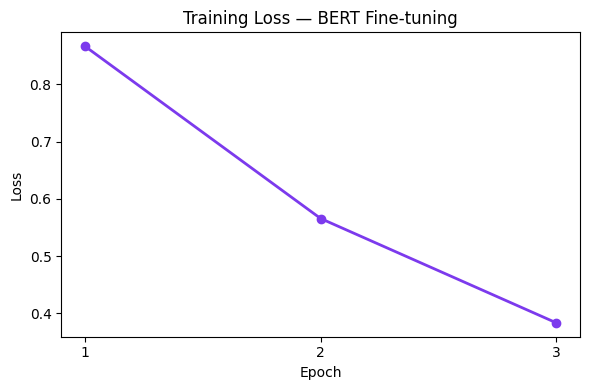

Loss curve saved to Drive.


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, 4), train_losses, marker='o', color='#7c3aed', linewidth=2)
plt.title('Training Loss — BERT Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks([1, 2, 3])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/multimodal_emotion/results/bert_loss_curve.png',
            dpi=150)
plt.show()
print("Loss curve saved to Drive.")